# End-to-End

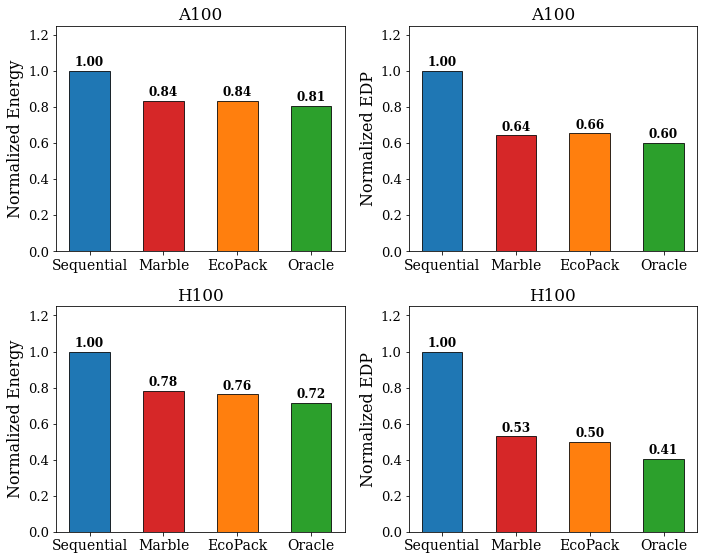

In [15]:
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import re
from pathlib import Path

matplotlib.rcParams.update({
    'font.size': 14,
    'font.family': 'serif',
    'axes.labelsize': 16,

    'xtick.labelsize': 14,
    'ytick.labelsize': 13,
})

RESULTS_ROOT = Path.home() / "power/GPGPU/coSched/results"
SYSTEMS = ["A100", "H100", "V100"]

POLICY_FILES = {
    "Sequential": "run_cosched_sequential.txt",
    "Marble":     "run_cosched_marble.txt",
    "EcoPack":    "EcoPack_cmab_run.txt",
    "Oracle":     "solver_execution_run.txt",
}

def parse_energy_makespan(filepath: Path):
    """Extract Total GPU energy (kJ) and Total makespan (s) from a result file."""
    text = filepath.read_text()
    energy_m = re.search(r"Total GPU energy:\s+([0-9.]+)\s+J", text)
    makespan_m = re.search(r"Total makespan:\s+([0-9.]+)s", text)
    if not energy_m or not makespan_m:
        return None, None
    return float(energy_m.group(1)) / 1000.0, float(makespan_m.group(1))

# Collect data per system
system_data = {}
for sys_name in SYSTEMS:
    sys_dir = RESULTS_ROOT / sys_name
    if not sys_dir.exists():
        continue
    policies_found = {}
    for policy, fname in POLICY_FILES.items():
        fpath = sys_dir / fname
        if not fpath.exists():
            continue
        energy_kj, makespan_s = parse_energy_makespan(fpath)
        if energy_kj is not None:
            policies_found[policy] = {"energy_kj": energy_kj, "makespan_s": makespan_s}
    if policies_found:
        system_data[sys_name] = policies_found

# Plot: one row per system, two columns (energy, EDP)
n_sys = len(system_data)
colors_map = {
    "Sequential": "#1f77b4",
    "Marble": "#d62728",
    "EcoPack": "#ff7f0e",
    "Oracle": "#2ca02c",
}

fig, axes = plt.subplots(n_sys, 2, figsize=(10, 4 * n_sys), squeeze=False)

for row, (sys_name, pdata) in enumerate(system_data.items()):
    policies = list(pdata.keys())
    energy_kj = [pdata[p]["energy_kj"] for p in policies]
    makespan_s = [pdata[p]["makespan_s"] for p in policies]
    edp = [e * m for e, m in zip(energy_kj, makespan_s)]
    colors = [colors_map.get(p, "gray") for p in policies]

    for col, (vals, ylabel) in enumerate([(energy_kj, "Energy (kJ)"), (edp, "EDP (kJ·s)")]):
        ax = axes[row, col]
        norm_vals = [v / vals[0] for v in vals]  # normalize to Sequential
        bars = ax.bar(policies, norm_vals, color=colors, edgecolor='black',
                      linewidth=0.8, width=0.55)
        for bar, val in zip(bars, norm_vals):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                    f'{val:.2f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
        ax.set_ylabel(f"Normalized {ylabel.split('(')[0].strip()}")
        ax.set_ylim(0, max(norm_vals) * 1.25)
        ax.set_title(f"{sys_name}")

plt.tight_layout()
plt.savefig('./fig/energy_comparison.png', dpi=300)
plt.show()


# Per-job performance

In [26]:
from pathlib import Path
import re
import pandas as pd

DATA_ROOT = Path.home() / "power/GPGPU/data"
RESULTS_ROOT = Path.home() / "power/GPGPU/coSched/results"
# SYSTEMS = ["A100","H100","V100"]
SYSTEMS=["H100","A100"]

# # Old approach: parse perf_metrics.txt for best runtime
# def parse_perf_best_runtime(path: Path):
#     lines = path.read_text().splitlines()
#     section_re = re.compile(r"^===== .*?/([^/ ]+) =====$")
#     current_app = None
#     rows = {}
#     for raw in lines:
#         line = raw.strip()
#         if not line:
#             continue
#         m = section_re.match(line)
#         if m:
#             current_app = m.group(1)
#             rows[current_app] = {}
#             continue
#         if current_app is None or line.startswith("cap=") or line.startswith("gpu_count"):
#             continue
#         parts = line.split()
#         if len(parts) < 3:
#             continue
#         gpu_count = int(parts[0])
#         runtime_s = float(parts[1])
#         rows[current_app][gpu_count] = runtime_s
#     best_runtime = {}
#     best_gpu = {}
#     for app, app_rows in rows.items():
#         g = min(app_rows, key=app_rows.get)
#         best_gpu[app] = g
#         best_runtime[app] = app_rows[g]
#     return best_runtime, best_gpu

def parse_sequential_bestgpu_runtime(path: Path):
    """Parse run_cosched_sequential_bestGPU.txt summary table for baseline runtimes."""
    lines = path.read_text().splitlines()
    # Find the summary section
    start = next((i for i, line in enumerate(lines) if line.strip() == "Sequential summary:"), None)
    if start is None:
        return {}, {}
    runtimes = {}
    gpu_counts = {}
    # Summary format: App  #GPUs  GPU IDs  Runtime (s)
    for line in lines[start + 3:]:
        s = line.strip()
        if not s or set(s) == {"-"}:
            break
        # Match: app_name  gpu_count  [gpu_ids]  runtime
        m = re.match(r"^\s*(\S+)\s+(\d+)\s+\[.*?\]\s+([0-9.]+)\s*$", line)
        if m:
            app = m.group(1)
            gpu_counts[app] = int(m.group(2))
            runtimes[app] = float(m.group(3))
    return runtimes, gpu_counts

def parse_online_runtime(path: Path):
    """Parse EcoPack online co-schedule summary for runtimes and GPU counts."""
    lines = path.read_text().splitlines()
    start = next((i for i, line in enumerate(lines) if line.strip() == "Online co-schedule summary:"), None)
    if start is None:
        return {}, {}
    runtimes = {}
    gpu_counts = {}
    # Summary format: App  #GPUs  GPU IDs  NUMA  Runtime (s)
    for line in lines[start + 3:]:
        s = line.strip()
        if not s or set(s) == {"-"}:
            break
        m = re.match(r"^\s*(\S+)\s+(\d+)\s+\[.*?\]\s+\d+\s+([0-9.]+)\s*$", line)
        if m:
            app = m.group(1)
            gpu_counts[app] = int(m.group(2))
            runtimes[app] = float(m.group(3))
    return runtimes, gpu_counts

all_dfs = {}
for sys_name in SYSTEMS:
    baseline_path = RESULTS_ROOT / sys_name / "run_cosched_sequential_bestGPU.txt"
    online_path = RESULTS_ROOT / sys_name / "EcoPack_cmab_run.txt"
    if not baseline_path.exists() or not online_path.exists():
        print(f"[{sys_name}] Skipping — missing run_cosched_sequential_bestGPU.txt or EcoPack_cmab_run.txt")
        continue

    baseline_rt, baseline_gpu = parse_sequential_bestgpu_runtime(baseline_path)
    online_rt, online_gpu = parse_online_runtime(online_path)
    if not online_rt:
        print(f"[{sys_name}] Skipping — no online summary found")
        continue

    apps = sorted(set(baseline_rt) & set(online_rt))
    rows = []
    for app in apps:
        base = baseline_rt[app]
        online = online_rt[app]
        rows.append({
            "app": app,
            "system": sys_name,
            "baseline_gpu": baseline_gpu[app],
            "ecopack_gpu": online_gpu[app],
            "baseline_runtime_s": base,
            "online_runtime_s": online,
            "runtime_delta_s": online - base,
            "runtime_increase_pct": (online - base) / base * 100.0,
            "performance_loss_pct": (1.0 - (base / online)) * 100.0,
        })

    df = pd.DataFrame(rows)
    all_dfs[sys_name] = df

In [10]:
for sys_name, df in all_dfs.items():
    print(f"\n{'='*60}")
    print(f"  {sys_name} — Per-Job Performance Results")
    print(f"{'='*60}")
    display(df)


  H100 — Per-Job Performance Results


,app,system,baseline_gpu,baseline_runtime_s,online_runtime_s,runtime_delta_s,runtime_increase_pct,performance_loss_pct
0,MonteCarloMultiGPU,H100,1,15.02,16.02,1.00,6.657790,6.242197
1,bert,H100,4,21.24,28.03,6.79,31.967985,24.224046
2,cloverleaf,H100,4,17.33,20.02,2.69,15.522216,13.436563
3,conjugateGradientMultiDeviceCG,H100,4,14.06,15.02,0.96,6.827881,6.391478
4,gpt2,H100,3,19.75,23.03,3.28,16.607595,14.242293
5,hpgmg,H100,1,8.41,13.01,4.60,54.696790,35.357417
6,lbm,H100,4,20.52,20.02,-0.50,-2.436647,-2.497502
7,minisweep,H100,4,43.83,45.05,1.22,2.783482,2.708102
8,miniweather,H100,1,57.91,59.07,1.16,2.003108,1.963772
9,pot3d,H100,4,109.45,120.14,10.69,9.767017,8.897952



  A100 — Per-Job Performance Results


,app,system,baseline_gpu,baseline_runtime_s,online_runtime_s,runtime_delta_s,runtime_increase_pct,performance_loss_pct
0,resnet101,A100,2,59.79,60.06,0.27,0.451581,0.44955


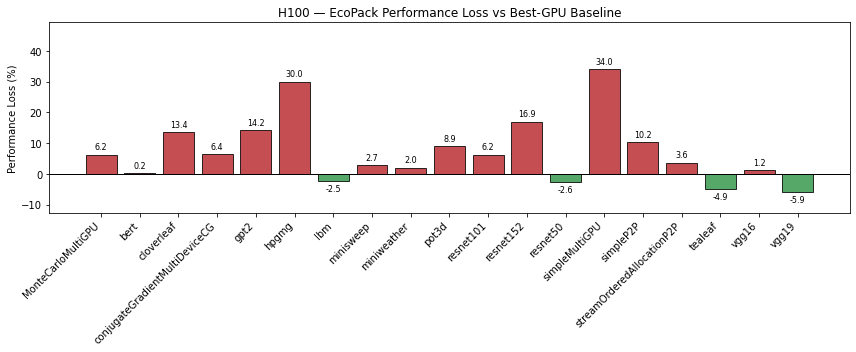


H100 — GPU Count Comparison:


,App,Best-Perf #GPUs,EcoPack #GPUs
0,MonteCarloMultiGPU,1,1
1,bert,4,4
2,cloverleaf,4,3
3,conjugateGradientMultiDeviceCG,4,4
4,gpt2,3,3
5,hpgmg,1,2
6,lbm,4,4
7,minisweep,4,4
8,miniweather,1,1
9,pot3d,4,2


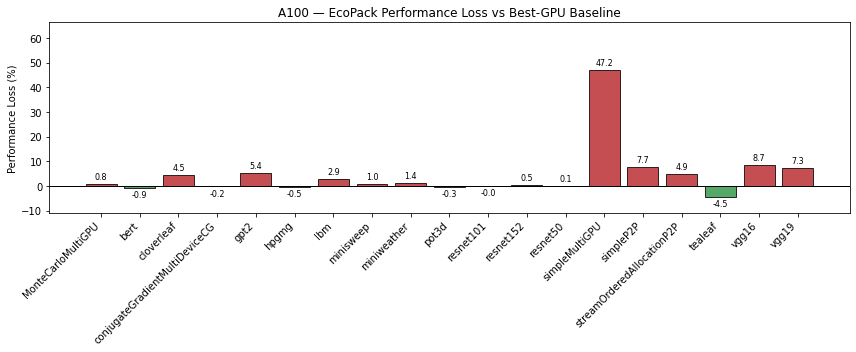


A100 — GPU Count Comparison:


,App,Best-Perf #GPUs,EcoPack #GPUs
0,MonteCarloMultiGPU,1,1
1,bert,4,4
2,cloverleaf,4,4
3,conjugateGradientMultiDeviceCG,2,2
4,gpt2,4,4
5,hpgmg,1,1
6,lbm,4,4
7,minisweep,4,4
8,miniweather,4,1
9,pot3d,4,4


In [27]:
import matplotlib.pyplot as plt

for sys_name, df in all_dfs.items():
    plot_df = df.reset_index(drop=True)
    x = range(len(plot_df))
    y = plot_df["performance_loss_pct"].values

    # Check if we need a broken axis (extreme negative outlier)
    need_break = y.min() < -100

    if need_break:
        fig, (ax_top, ax_bottom) = plt.subplots(
            2, 1, sharex=True, figsize=(12, 6),
            gridspec_kw={"height_ratios": [3, 1]}
        )
        ax_top.set_ylim(-50, max(y) * 1.3 + 5)
        ax_bottom.set_ylim(y.min() * 1.15, -100)

        colors = ["#C44E52" if v > 0 else "#55A868" for v in y]
        bar_kwargs = dict(edgecolor="black", linewidth=0.8)

        ax_top.bar(x, y, color=colors, **bar_kwargs)
        ax_bottom.bar(x, y, color=colors, **bar_kwargs)

        ax_top.spines["bottom"].set_visible(False)
        ax_bottom.spines["top"].set_visible(False)
        ax_top.tick_params(labeltop=False, bottom=False)
        ax_bottom.xaxis.tick_bottom()

        d = 0.008
        kwargs = dict(transform=ax_top.transAxes, color="k", clip_on=False)
        ax_top.plot((-d, +d), (-d, +d), **kwargs)
        ax_top.plot((1 - d, 1 + d), (-d, +d), **kwargs)
        kwargs.update(transform=ax_bottom.transAxes)
        ax_bottom.plot((-d, +d), (1 - d, 1 + d), **kwargs)
        ax_bottom.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

        ax_top.axhline(0, color="black", linewidth=1)
        ax_bottom.set_xticks(list(x))
        ax_bottom.set_xticklabels(plot_df["app"], rotation=45, ha="right")
        ax_top.set_ylabel("Performance Loss (%)")
        ax_top.set_title(f"{sys_name} — EcoPack Performance Loss vs Best-GPU Baseline")

        for i, v in enumerate(y):
            if v < -100:
                ax_bottom.text(i, v - 5, f"{v:.1f}", ha="center", va="top", fontsize=8)
            else:
                va = "bottom" if v >= 0 else "top"
                offset = 1.0 if v >= 0 else -1.0
                ax_top.text(i, v + offset, f"{v:.1f}", ha="center", va=va, fontsize=8)
    else:
        fig, ax = plt.subplots(figsize=(12, 5))
        colors = ["#C44E52" if v > 0 else "#55A868" for v in y]
        bars = ax.bar(x, y, color=colors, edgecolor="black", linewidth=0.8)
        ax.axhline(0, color="black", linewidth=1)
        ax.set_xticks(list(x))
        ax.set_xticklabels(plot_df["app"], rotation=45, ha="right")
        ax.set_ylabel("Performance Loss (%)")
        ax.set_title(f"{sys_name} — EcoPack Performance Loss vs Best-GPU Baseline")
        ax.set_ylim(min(y) * 1.3 - 5, max(y) * 1.3 + 5)

        for i, v in enumerate(y):
            va = "bottom" if v >= 0 else "top"
            offset = 1.0 if v >= 0 else -1.0
            ax.text(i, v + offset, f"{v:.1f}", ha="center", va=va, fontsize=8)

    plt.tight_layout()
    plt.savefig(f'./fig/perf_loss_{sys_name}.png', dpi=300)
    plt.show()

    # Print GPU count comparison table
    gpu_table = plot_df[["app", "baseline_gpu", "ecopack_gpu"]].copy()
    gpu_table.columns = ["App", "Best-Perf #GPUs", "EcoPack #GPUs"]
    print(f"\n{sys_name} — GPU Count Comparison:")
    display(gpu_table)